In [3]:
import torch
print (torch.cuda.is_available())
print (torch.cuda.device_count())
print (torch.cuda.current_device())

import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc

import matplotlib.pyplot as plt

import seaborn as sns
from matplotlib.lines import Line2D
import umap

import scvi
from scvi.model import CondSCVI, DestVI

import torch

%matplotlib inline

/home/ajita/anaconda3/envs/scvi-env/lib/python3.9/site-packages/scvi/_settings.py:63: UserWarning: Since v1.0.0, scvi-tools no longer uses a random seed by default. Run `scvi.settings.seed = 0` to reproduce results from previous versions.
  self.seed = seed
/home/ajita/anaconda3/envs/scvi-env/lib/python3.9/site-packages/scvi/_settings.py:70: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  self.dl_pin_memory_gpu_training = (


### Specify path

In [4]:
data_path = "/data/Ajita/Spatial/Datasets/Spatial_Deconvolution/Breast_Atlas/SC/SC.h5ad"
results_path = "/data/Ajita/Spatial/Datasets/Spatial_Deconvolution/Breast_Atlas/final_outputs/ST_8/"

sc_adata = sc.read_h5ad(data_path)
celltype_col = "broad_cell_type"


### Preprocessing Datasets

In [5]:
G=2000
sc.pp.filter_genes(sc_adata, min_counts=10)

sc_adata.layers["counts"] = sc_adata.X.copy()

sc.pp.highly_variable_genes(
  sc_adata,
    n_top_genes=G,
    subset=True,
    layer="counts",
    flavor="seurat_v3"
)

sc.pp.normalize_total(sc_adata, target_sum=10e4)
sc.pp.log1p(sc_adata)
sc_adata.raw = sc_adata


AnnData object with n_obs × n_vars = 714331 × 2000
    obs: 'mapped_reference_assembly', 'mapped_reference_annotation', 'alignment_software', 'donor_id', 'self_reported_ethnicity_ontology_term_id', 'donor_living_at_sample_collection', 'donor_menopausal_status', 'organism_ontology_term_id', 'sample_uuid', 'sample_preservation_method', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'sample_derivation_process', 'sample_source', 'donor_BMI_at_collection', 'suspension_depleted_cell_types', 'suspension_derivation_process', 'suspension_dissociation_reagent', 'suspension_dissociation_time', 'suspension_percent_cell_viability', 'suspension_uuid', 'suspension_type', 'library_uuid', 'assay_ontology_term_id', 'sequencing_platform', 'is_primary_data', 'cell_type_ontology_term_id', 'author_cell_type', 'cell_state', 'disease_ontology_term_id', 'sex_ontology_term_id', 'n_count_rna', 'n_feature_rna', 'percent_mito', 'percent_rb', 'tissue_location', 'bmi_group', 'procedure_group', 'age

### Reading Spatial Data

In [7]:

data_path = "/data/Ajita/Spatial/Datasets/Spatial_Deconvolution/Breast_Atlas/simulator_outputs/ST_8/"
st_adata = sc.read_h5ad(data_path + "simulated_gene_expression_average.h5ad")

st_adata.obs_names_make_unique()
st_adata.var_names = pd.Categorical(st_adata.var_names).astype(str)
st_adata.var_names_make_unique()


In [9]:

st_adata.layers["counts"] = st_adata.X.copy()

sc.pp.normalize_total(st_adata, target_sum = 10e4)
sc.pp.log1p(st_adata)
st_adata.raw = st_adata

intersect = np.intersect1d(st_adata.var_names, sc_adata.var_names) 
st_adata = st_adata[:,intersect].copy()
sc_adata = sc_adata[:,intersect].copy()

G = len(intersect)


### Fit the scLVM

In [ ]:
CondSCVI.setup_anndata(sc_adata, layer = 'counts', labels_key = celltype_col)
sc_model = CondSCVI(sc_adata, weight_obs = True)
sc_model.train(max_epochs = 250)
sc_model.history['elbo_train'].plot()
sc_model.save('./sc_model_breast_atlas_simulated', overwrite=True, save_anndata=True)
sc_adata.obsm["X_scVI"]=sc_model.get_latent_representation()

###### use scVI latent space for UMAP generation
sc.pp.neighbors(sc_adata, use_rep="X_scVI")

sc.tl.umap(sc_adata, min_dist=0.3)

sc.pl.umap(
    sc_adata,
    color=[celltype_col],
    frameon=False,
)


### Deconvolution with stLVM

In [10]:
model_path = "./simulated/sc_model_breast_atlas_simulated"
sc_model = CondSCVI.load(model_path, sc_adata)


INFO     File ./simulated/sc_model_breast_atlas_simulated/model.pt already downloaded                              


/home/ajita/anaconda3/envs/scvi-env/lib/python3.9/abc.py:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

  return _abc_instancecheck(cls, instance)


/home/ajita/anaconda3/envs/scvi-env/lib/python3.9/abc.py:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

  return _abc_instancecheck(cls, instance)


AnnData object with n_obs × n_vars = 2801 × 1999
    obs: 'mapped_reference_assembly', 'mapped_reference_annotation', 'alignment_software', 'donor_id', 'self_reported_ethnicity_ontology_term_id', 'donor_living_at_sample_collection', 'donor_menopausal_status', 'organism_ontology_term_id', 'sample_uuid', 'sample_preservation_method', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'sample_derivation_process', 'sample_source', 'donor_BMI_at_collection', 'tissue_section_uuid', 'tissue_section_thickness', 'library_uuid', 'assay_ontology_term_id', 'sequencing_platform', 'is_primary_data', 'cell_type_ontology_term_id', 'author_cell_type', 'disease_ontology_term_id', 'sex_ontology_term_id', 'nCount_Spatial', 'nFeature_Spatial', 'nCount_SCT', 'nFeature_SCT', 'suspension_type', 'tissue_type', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'scaling_factors', 'umi_count_before_scaling', 'umi_count

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Epoch 2500/2500: 100%|████████████████████████████████████████████| 2500/2500 [16:11<00:00,  3.48it/s, v_num=1, train_loss_step=1.9e+6, train_loss_epoch=1.85e+6]

`Trainer.fit` stopped: `max_epochs=2500` reached.


Epoch 2500/2500: 100%|████████████████████████████████████████████| 2500/2500 [16:11<00:00,  2.57it/s, v_num=1, train_loss_step=1.9e+6, train_loss_epoch=1.85e+6]


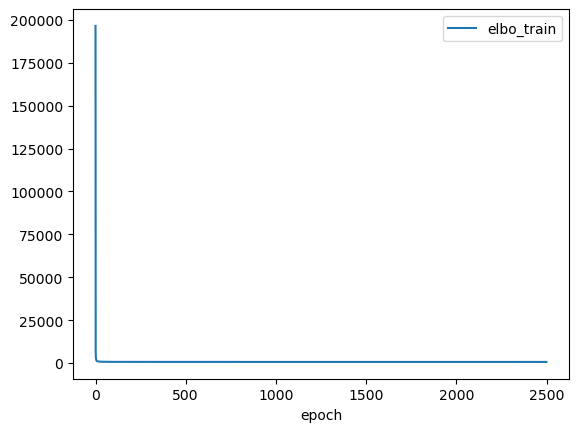

In [11]:
DestVI.setup_anndata(st_adata, layer="counts")
print (st_adata)
st_model = DestVI.from_rna_model(st_adata, sc_model)
st_model.train(max_epochs=2500)
st_model.history['elbo_train'].plot()
st_model.get_proportions().to_csv(results_path + "output_DestVI.csv")